# **Customer Segmentation**
**By Joshua Ozoaka**  
Unsipervised learning project dividing credit card provider customers into groups based on based on various attributes of their card info and usage. The hypothetical problem we're solving here is the division of a random dataset of customers into groups relating to their financial behavuours for the purpose of more individualised approaches to customer relations.  
First step, we load and inspect the dataset.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
from IPython.display import display

print(os.listdir())
warnings.filterwarnings('ignore')
cards = pd.read_csv("Customer Data.csv")

['.git', '.gitignore', '.ipynb_checkpoints', 'Customer Data.csv', 'customer segmentation.ipynb', 'Customer_Data (1).xlsx', 'experiments(2).ipynb', 'Experiments.ipynb', 'README.md']


In [2]:
cards

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [3]:
cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
cards.duplicated().sum()

np.int64(0)

In [5]:
cards.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Dataset has 8,950 observations and 18 labels. 314 missing values across 2 variables, with all but one of them coming from Minimum Payments. No duplicate entries, and all variables are in numerical data types.

# **Step 2**
Now, after inspection, we proceed to clean and preprocess our dataset. There is only one collection error identified, so this should be fairly straightforward.

In [6]:
cards.drop(columns='CUST_ID', inplace=True) # drop customer ID column

Missing data is concentrated in one variable, which leads me to beleive it is not missing completely at random. We'll ascertain what kind of missing data it is by mean computation.

In [7]:
cards['Missing'] = cards['MINIMUM_PAYMENTS'].isnull()
cards

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Missing
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,False
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,False
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,False
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,True
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,False
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6,True
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,False
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,False


In [8]:
non_missing = cards[cards['Missing'] == False]
missing = cards[cards['Missing'] == True]

non_missing_mean = non_missing['BALANCE'].mean()
missing_mean = missing['BALANCE'].mean()

diff = non_missing_mean - missing_mean

In [9]:
print(np.ptp(cards['BALANCE']))
diff

19043.13856


np.float64(1045.600310709348)

The difference between the means of the Balance values of the two groups is only around 1k. Given the range of the values displayed just above the difference, that would indicate this missingness is not telling of any valuable transactional or financial behaviour. But for surety, let's perform the same mean computation for payments made.

In [10]:
non_missing_pmean = non_missing['PAYMENTS'].mean()
missing_pmean = missing['PAYMENTS'].mean()

diff2 = non_missing_pmean - missing_pmean

In [11]:
print(np.ptp(cards['PAYMENTS']))
diff2

50721.48336


np.float64(1461.9863689166773)

The difference between the means of the mayments made by those with missing minimum payments values and those without is only 1461, only around 7% of the range of payments values.I think we can safely assume that the missing values are MCAR, and handle them accordingly. There are only 316 such entries out of 9k, so we can drop them and still retain a decent representation of the collection's tru tendencies.

In [12]:
cards.dropna(subset='MINIMUM_PAYMENTS', inplace=True)

In [13]:
cards['CREDIT_LIMIT'].fillna(value=cards['CREDIT_LIMIT'].median(), inplace=True)
cards.drop(columns='Missing', inplace=True)
cards.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

All missing values have been handled.

# Step 3
Here, we perform EDA by visualisation to understand our distributions and key relationships. Tho goal here is to understand where there is most covariation besides the obvious suspects, and to ascertain the kinds of distributions that the most important monetary features are. We start, however, with descriptive statistics

In [14]:
cards.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.00000
mean,1601.041632,0.894951,1025.315149,604.831402,420.794807,994.082050,0.495943,0.205885,0.368778,0.137608,3.313651,15.031492,4521.914800,1784.272537,864.206542,0.159285,11.53375
std,2095.519182,0.207833,2167.010602,1684.222861,917.203254,2121.353259,0.401285,0.300044,0.398090,0.201780,6.912151,25.179530,3659.065167,2909.704331,2372.446607,0.296259,1.31226
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163,0.000000,6.00000
25%,147.838347,0.909091,43.300000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,418.446951,169.123707,0.000000,12.00000
50%,916.749476,1.000000,375.240000,44.990000,94.710000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,896.300688,312.343947,0.000000,12.00000
75%,2104.961701,1.000000,1145.850000,598.950000,484.040000,1131.986387,0.916667,0.333333,0.750000,0.250000,4.000000,18.000000,6500.000000,1951.116757,825.485459,0.166667,12.00000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.00000


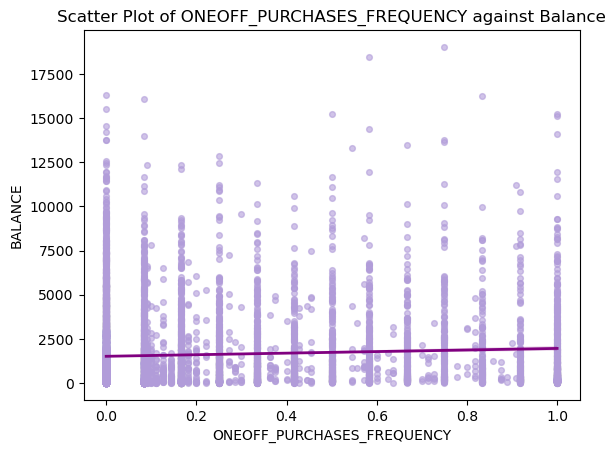

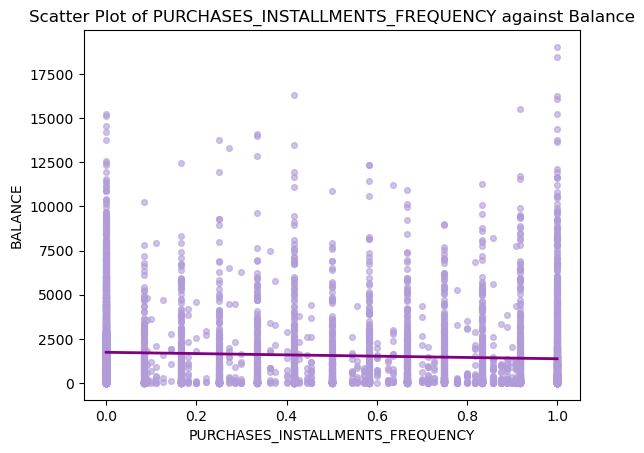

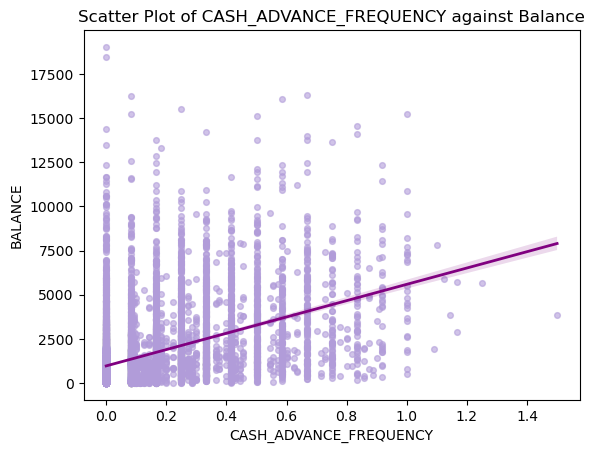

In [15]:
cols = ['ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']

for col in cols:
    sns.regplot(x=col, y='BALANCE', data=cards, line_kws={'color': 'purple', 'lw': 2}, color='#B19CD9', scatter_kws={'alpha': 0.6, 's': 17})
    plt.title(f"Scatter Plot of {col} against Balance")
    plt.show()

The graphs displayed above compare three different transactional behaviours to balance. Here's what we can infer;
- Graph 1 shows us the gently upward inclined line of best fit between one-off purchase frequency and outstanding credit card balance, hinting at a slight positive correlation between the two
- Graph 2 shows us that suprisingly, the only ostensible correlation between installment purchase frequency and outstanding credit balance is negative, be it slightly. One may have otherwise presumed to think to the contrary
- Graph 3 shows us a glaring positive correlation between cash advance frequency and credit balance, hinting that frequent cash withdrawal ad usage as opposed to direct credit card purchases may be a debt-incuring and accumulating behaviour.

In [16]:
cards['TOTAL_TRX'] = cards['CASH_ADVANCE_TRX'] + cards['PURCHASES_TRX']
cards['NETSPEND'] = cards['CASH_ADVANCE'] + cards['PURCHASES']

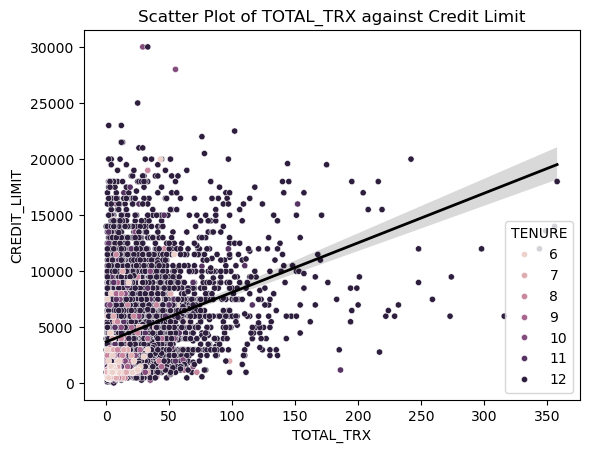

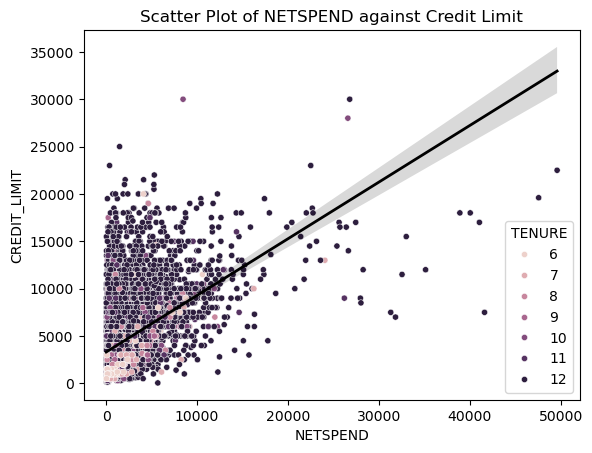

In [17]:
cols = ['TOTAL_TRX', 'NETSPEND']

for col in cols:
    sns.scatterplot(x=col, y='CREDIT_LIMIT', data=cards, s=20, hue='TENURE')
    sns.regplot(x=col, y='CREDIT_LIMIT', data=cards, line_kws={'color': 'black', 'lw': 2}, scatter=False) # plot scatter and reg in the same ax
    plt.title(f"Scatter Plot of {col} against Credit Limit")
    plt.show()

We can infer with some certainty from the regression plots above that a customer's credit limit increases with card usage, more steeply so with total amount spent than with number of transactions. That is, fewer transactions of greater amounts increase credit limit faster than more transactions of fewer amounts. Of course, both amount spent and transaction number increasing with card usage tenure.

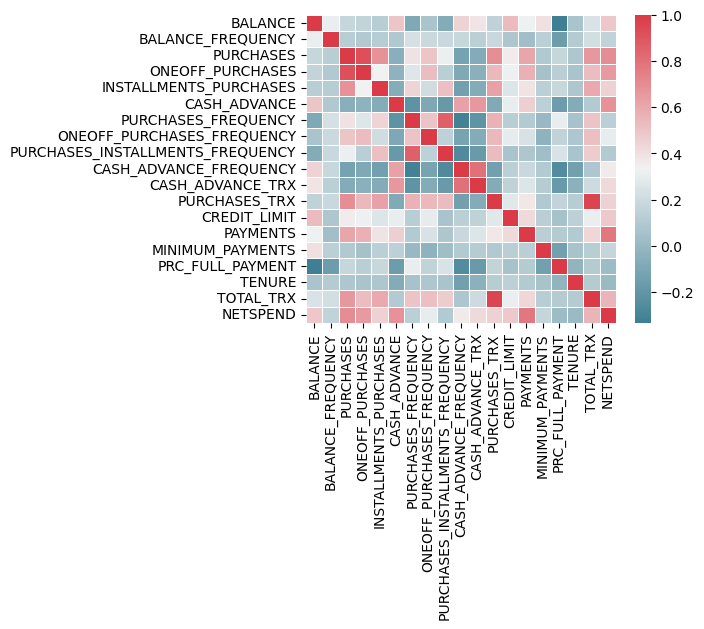

In [18]:
cmap = sns.diverging_palette(220, 10, as_cmap=True)
mask = np.zeros_like(cards.corr(), dtype=np.bool) # create mask for upper triangle
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(5,4))
sns.heatmap(data=cards.corr(), cmap=cmap, mask=mask, linewidths=.5)
plt.show()

The heatmap shows that there's considerable correlation all over the dataset. One may have already inferred this, however, as all attributes are eiher monetary or measures of financial behaviour. Principal Component Analysis (PCA) will help make good of all the covariation.

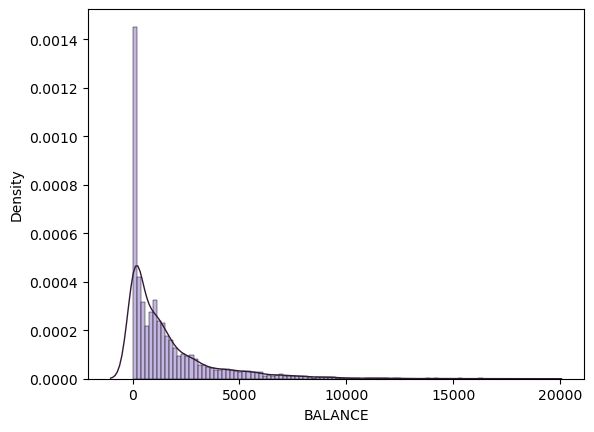

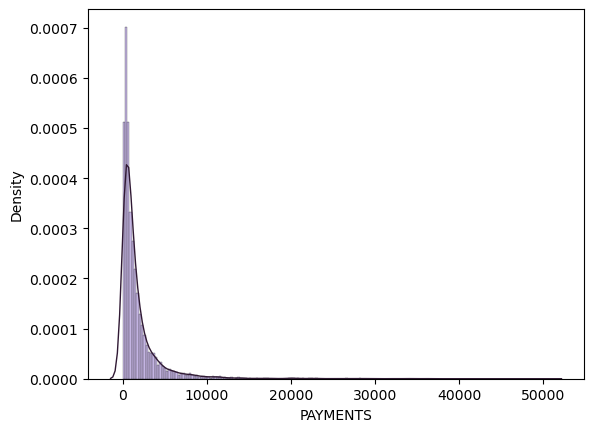

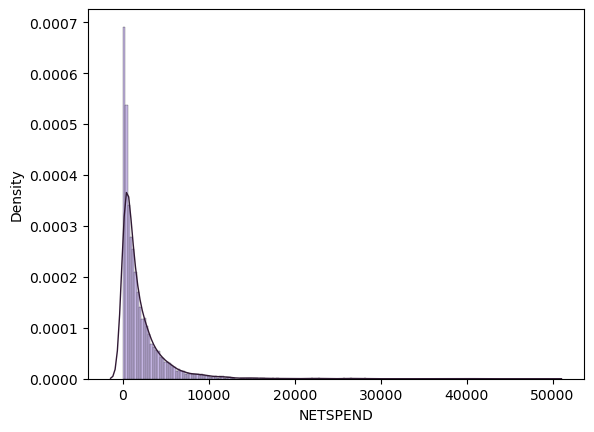

In [19]:
cols = ['BALANCE', 'PAYMENTS', 'NETSPEND']

for col in cols:
    sns.histplot(x=col, data=cards, stat="density", color="#B19CD9", edgecolor="black")
    sns.kdeplot(x=col, data=cards, color="#301934", linewidth=1)
    plt.show()

These KDE plots show that our variables make highly leptokurtotic distributions and are very right-skewed, with several outlier and extreme observations that lie far from the general tendency. This is often the case with monetary variables, however it calls for additional preprocessing steps to normalise the data before clustering. First, let's explore what variables will need normalisation, besides the three plotted above.

In [20]:
cards.columns.tolist() # lists out the columns list

['BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE',
 'TOTAL_TRX',
 'NETSPEND']

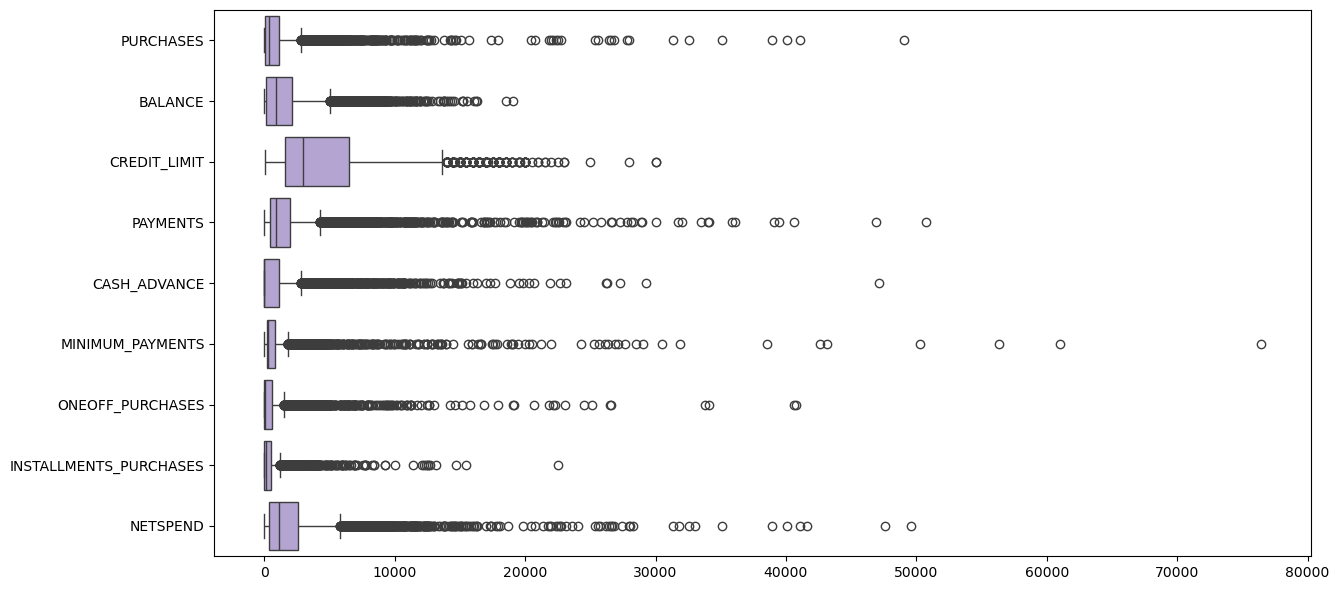

In [21]:
cols = ['PURCHASES', 'BALANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'CASH_ADVANCE', 'MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'NETSPEND']

fig, ax = plt.subplots(figsize=(len(cols) * 1.5, 6)) # create custom figure and axes to be used

sns.boxplot(data=cards[cols], color='#B19CD9', ax=ax, orient='h')
plt.tight_layout()
plt.show()

The boxplots above further show how right skewed most of our monetary variables are, with the most manageable being credit limit. The rest of our variables displayed above have terribly narrow Inter Quartile Ranges in contrast to the range of the entire column, with loads of extreme values lying at the opposite end to the most dense region. We will take this into consideration in preprocessing to prevent this tendency from affecting our clustering.

# Step 4
Now, we carry out all remaining preprocessing to prepare the data for modelling.

The previous graph gave us a good understanding of the distribution of outliers in our columns. We begin this section by exploring their numbers.

In [22]:
table = []
# define func to show outliers
def show_outliers(column):
    Q1 = cards[column].quantile(0.25)
    Q3 = cards[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = cards[(cards[column] > Q3 + (1.5 * IQR)) | (cards[column] < Q1 - (1.5 * IQR))]
    table.append({
        'Column': column,
        'Outlier count': len(outliers),
        'Outlier %': (len(outliers) / len(cards)) * 100
    })
    return len(outliers)

In [23]:
cols.remove('CREDIT_LIMIT')

for col in cols:
    show_outliers(col)

In [24]:
pd.DataFrame(table)

,Column,Outlier count,Outlier %
0,PURCHASES,768,8.891976
1,BALANCE,666,7.711011
2,PAYMENTS,785,9.088804
3,CASH_ADVANCE,977,11.311798
4,MINIMUM_PAYMENTS,841,9.737177
5,ONEOFF_PURCHASES,961,11.126549
6,INSTALLMENTS_PURCHASES,811,9.389834
7,NETSPEND,600,6.946857


Considering both the number and extremity of the outliers in the columns above, I think there is need to log transform our variables before scaling.

In [25]:
cards[cols] = np.log1p(cards[cols]) # numpy log transformation func

In [26]:
cards

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,TOTAL_TRX,NETSPEND
0,3.735304,0.818182,4.568506,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,5.312231,4.945277,0.000000,12,2,4.568506
1,8.071989,0.909091,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,8.319725,6.978531,0.222222,12,4,8.770896
2,7.822504,1.000000,6.651791,6.651791,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,6.434654,6.442994,0.000000,12,12,6.651791
4,6.707735,1.000000,2.833213,2.833213,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,6.521114,5.504483,0.000000,12,1,2.833213
5,7.501540,1.000000,7.196147,0.000000,7.196147,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,7.244983,7.786654,0.000000,12,8,7.196147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,1.927413,0.500000,3.086487,3.086487,0.000000,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,4.088408,3.794898,0.000000,6,1,3.086487
8945,3.384170,1.000000,5.677165,0.000000,5.677165,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,5.788719,3.909748,0.500000,6,6,5.677165
8947,3.194529,0.833333,4.979489,0.000000,4.979489,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,4.410016,4.423869,0.250000,6,5,4.979489
8948,2.671218,0.833333,0.000000,0.000000,0.000000,3.625907,0.000000,0.000000,0.000000,0.166667,2,0,500.0,3.980615,4.038755,0.250000,6,2,3.625907


In [27]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [28]:
cols = cards.columns.tolist()

cards[cols] = sc.fit_transform(cards[cols]) # scale each column in the list

In [29]:
cards

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,TOTAL_TRX,NETSPEND
0,-1.334348,-0.369399,-0.123104,-0.995909,0.382099,-0.937995,-0.820601,-0.686221,-0.717078,-0.682008,-0.479423,-0.517573,-0.962573,-1.293972,-0.820647,-0.537687,0.355324,-0.637493,-1.655024
1,0.952818,0.068040,-1.686076,-0.995909,-1.095968,1.518317,-1.235958,-0.686221,-0.926422,0.557037,0.099302,-0.597007,0.677285,1.296746,0.887361,0.212451,0.355324,-0.559489,1.410253
2,0.821240,0.505480,0.589627,1.049267,-1.095968,-0.937995,1.256181,2.646812,-0.926422,-0.682008,-0.479423,-0.120402,0.813939,-0.327094,0.437490,-0.537687,0.355324,-0.247473,-0.135449
4,0.233311,0.505480,-0.716780,-0.124802,-1.095968,-0.937995,-1.028281,-0.408470,-0.926422,-0.682008,-0.479423,-0.557290,-0.907911,-0.252615,-0.350894,-0.537687,0.355324,-0.676495,-2.920769
5,0.651964,0.505480,0.775861,-0.995909,1.232229,-0.937995,0.425469,-0.686221,0.538994,-0.682008,-0.479423,-0.279270,-0.743926,0.370940,1.566214,-0.537687,0.355324,-0.403481,0.261611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,-2.287829,-1.900441,-0.630131,-0.046930,-1.095968,-0.937995,-0.820601,-0.130715,-0.926422,-0.682008,-0.479423,-0.557290,-1.099228,-2.348197,-1.787008,-0.537687,-4.217207,-0.676495,-2.736028
8945,-1.519536,0.505480,0.256189,-0.995909,0.740787,-0.937995,1.256181,-0.686221,1.167029,-0.682008,-0.479423,-0.358705,-0.962573,-0.883515,-1.690530,1.150125,-4.217207,-0.481485,-0.846354
8947,-1.619553,-0.296495,0.017501,-0.995909,0.515065,-0.937995,0.840824,-0.686221,0.748340,-0.682008,-0.479423,-0.398422,-0.962573,-2.071158,-1.258650,0.306219,-4.217207,-0.520487,-1.355248
8948,-1.895547,-0.296495,-1.686076,-0.995909,-1.095968,0.077450,-1.235958,-0.686221,-0.926422,0.144024,-0.190060,-0.597007,-1.099228,-2.441052,-1.582160,0.306219,-4.217207,-0.637493,-2.342568


# Step 5
Now that we've fully preprocessed out dataset, we perform dimentionality reduction using Principal Component Analysis (PCA) to address unify covariation before clustering.

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components=12, random_state=42)

In [31]:
pca.fit(cards)

,n_components,12
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [32]:
matrix = pd.DataFrame(pca.fit_transform(cards)).rename({i: f"PC{i+1}" for i in range(12)}, axis=1)
matrix

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-1.900021,-2.644092,-0.382580,-0.577223,0.058599,0.880569,0.317809,-0.306834,0.300670,0.117975,0.358214,-0.188441
1,-2.084596,2.688121,0.293150,0.256743,1.601032,-0.684713,-0.855310,0.686825,-0.866711,-0.474179,-0.252498,0.051286
2,1.294262,0.188082,2.132512,-2.076314,-0.920479,-0.475093,0.306823,0.193091,1.048056,-0.137125,-0.418795,1.327336
3,-2.306403,-1.457047,0.389194,-2.001389,-0.091930,0.808143,0.169393,0.699752,0.450287,0.660628,1.179953,0.445467
4,0.656480,-0.188943,-1.905282,-1.495208,0.548241,-0.704623,-0.062277,-0.463122,-0.908423,0.974271,0.198294,0.108739
...,...,...,...,...,...,...,...,...,...,...,...,...
8632,-3.228720,-4.101509,1.108322,1.413415,-3.653992,0.478688,-1.700635,-0.623020,0.756433,0.724203,0.563295,0.597874
8633,-0.057866,-3.384213,-1.775595,2.039239,-2.770453,-1.804274,-1.348906,0.848331,0.231696,0.005333,1.110308,0.271990
8634,-1.021335,-3.623544,-1.577283,1.606610,-3.224438,-0.994647,-1.602967,-0.002312,0.652250,0.324767,0.422151,0.300271
8635,-4.083404,-2.775654,-0.139266,1.800860,-3.338200,0.159733,-1.753277,1.036166,1.093682,0.150866,0.383282,0.167042


Displayed above is the dataset reduced into 12 dimensions. This is only an initial guess, not too far from the original 18. We'll explore their cumulative and indiidual explained variance, and thence decide how many components to retain.

In [33]:
array = []
array.append(pd.Series(matrix.columns.tolist()))
array.append(pd.Series(pca.explained_variance_ratio_ * 100))
array.append(pd.Series(pca.explained_variance_ratio_ * 100).cumsum()) # cummulative summation across series

In [34]:
components = pd.DataFrame(array).T.rename({0: 'Components', 1: 'Explained Variance', 2: 'Cumulative EV'}, axis=1)

In [35]:
cols = ['Explained Variance', 'Cumulative EV']

components[cols] = components[cols].map(lambda x: f"{x:,.0f}%") # transformation across series or df
components

,Components,Explained Variance,Cumulative EV
0,PC1,30%,30%
1,PC2,24%,53%
2,PC3,8%,62%
3,PC4,8%,70%
4,PC5,6%,76%
5,PC6,5%,80%
6,PC7,4%,84%
7,PC8,4%,88%
8,PC9,3%,91%
9,PC10,2%,93%


Given the table above, I believe retaining 10 of our principal components balances dimensionality reduction and variation preservation, leaving us with 93% of our variance.

In [36]:
pca = PCA(n_components=10, random_state=42)

reduced = pd.DataFrame(pca.fit_transform(cards)).rename({i: f"PC{i+1}" for i in range(10)}, axis=1)

In [37]:
reduced

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-1.900021,-2.644092,-0.382580,-0.577223,0.058599,0.880569,0.317809,-0.306834,0.300670,0.117975
1,-2.084596,2.688121,0.293150,0.256743,1.601032,-0.684713,-0.855310,0.686825,-0.866711,-0.474179
2,1.294262,0.188082,2.132512,-2.076314,-0.920479,-0.475093,0.306823,0.193091,1.048056,-0.137125
3,-2.306403,-1.457047,0.389194,-2.001389,-0.091930,0.808143,0.169393,0.699752,0.450287,0.660628
4,0.656480,-0.188943,-1.905282,-1.495208,0.548241,-0.704623,-0.062277,-0.463122,-0.908423,0.974271
...,...,...,...,...,...,...,...,...,...,...
8632,-3.228720,-4.101509,1.108322,1.413415,-3.653992,0.478688,-1.700635,-0.623020,0.756433,0.724203
8633,-0.057866,-3.384213,-1.775595,2.039239,-2.770453,-1.804274,-1.348906,0.848331,0.231696,0.005333
8634,-1.021335,-3.623544,-1.577283,1.606610,-3.224438,-0.994647,-1.602967,-0.002312,0.652250,0.324767
8635,-4.083404,-2.775654,-0.139266,1.800860,-3.338200,0.159733,-1.753277,1.036166,1.093682,0.150866


Displayed above is our dataset reduced to our final pick of 10 components. Now let's explore what each of these actually represents with their loadings.

In [38]:
loadings = pd.DataFrame(pca.components_, index=reduced.columns.tolist()).T.rename({
    i: pd.Series(cards.columns.tolist()).iloc[i] for i in range(19) # iloc is like the inverse of index
})

In [39]:
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
BALANCE,0.034929,0.399796,-0.093344,-0.317191,-0.062664,-0.109188,-0.148427,0.021071,-0.090438,0.096732
BALANCE_FREQUENCY,0.106114,0.208531,-0.277577,-0.373918,-0.164243,-0.196356,0.152109,0.537056,0.264479,-0.258259
PURCHASES,0.356631,-0.099685,0.070151,-0.041847,-0.116208,-0.182277,0.220783,-0.272228,-0.030165,0.222404
ONEOFF_PURCHASES,0.266948,0.061105,0.460225,-0.139382,-0.258922,-0.061018,0.227958,-0.147002,-0.028090,0.093718
INSTALLMENTS_PURCHASES,0.316908,-0.117276,-0.367496,0.092353,0.081766,-0.103363,0.029947,-0.224022,-0.043565,0.012966
CASH_ADVANCE,-0.156594,0.363231,-0.064974,0.192263,-0.036489,-0.009939,0.019297,-0.005055,-0.190828,-0.351919
PURCHASES_FREQUENCY,0.361256,-0.109902,-0.211695,0.027217,-0.110415,-0.154484,0.152024,-0.036344,0.072512,-0.114659
ONEOFF_PURCHASES_FREQUENCY,0.285537,0.057624,0.412421,-0.079499,-0.243877,0.021283,0.137540,0.171586,0.109382,-0.143087
PURCHASES_INSTALLMENTS_FREQUENCY,0.306110,-0.113453,-0.451908,0.087611,0.035849,-0.053941,0.013423,-0.117368,-0.000356,-0.130764
CASH_ADVANCE_FREQUENCY,-0.113591,0.357468,-0.092401,0.319589,-0.123711,0.037407,0.259254,-0.042978,0.168726,-0.007511


The table above shows us, column wise, the loadings of the linear combinations that make up each principal component, giving insught into what thes new axes actually represent. Given that there are quite a few columns that make up these components, they aren't quite as interpretable as the colums themselves, but they do effectively represent our information.  
PC1 seems to represent purchase magnitude and frequency more than anything else, as it has large positive loadings for related variables.  
PC2 seems to be related to balance, cash advance and payments.  
PC3 appears positively correlated with one-off purchases and negatively so with installments purchases.  
PC4 and PC5 have the strongest negative and positive loadings for tenure respectively.  
PC8 has strong loadings for balance frequency and proportion of full payments.  

# Step 5
Now, we carry out our clustering with the transformed, scaled, reduced feature space

### K-Means Clustering

In [40]:
from sklearn.cluster import KMeans

In [41]:
inertias = []
values = range(1,9)

for value in values:
    km = KMeans(n_clusters=value, n_init=10, random_state=42)
    km.fit(reduced)
    inertias.append(km.inertia_)

In [42]:
elbow = []
elbow.append(values)
elbow.append(inertias)
table = pd.DataFrame(elbow).T.rename({0: "Cluster Numbers", 1: "Inertia Values"}, axis=1)
table

,Cluster Numbers,Inertia Values
0,1.0,153145.318706
1,2.0,119954.824501
2,3.0,97623.116080
3,4.0,88873.827831
4,5.0,81232.791361
5,6.0,73805.112871
6,7.0,68694.977453
7,8.0,64771.916723


Here, we've fit 8 different K-Means clustering models onto our data and taken the inertia values they all produced, inertia being sum of squares of deviations from centroid within clusters. Given that the objective here is segmentation, clusterings that have observations closer together - hence those that have lower inertia values - seem like the way to go, but an optimal value balances low inertia and low complexity - not having too many clusters. We'll use the elbow method, which selects the K value at which the inertia graph changes direction most drastically.

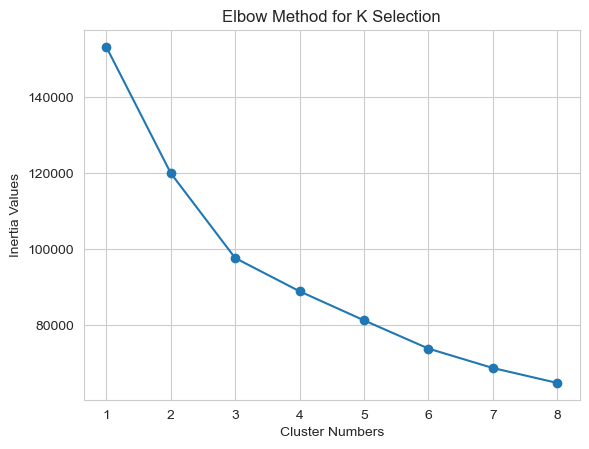

In [43]:
sns.set_style("whitegrid")
table.plot(x="Cluster Numbers", y="Inertia Values", marker="o", legend=None)
plt.ylabel("Inertia Values")
plt.title("Elbow Method for K Selection")
plt.show()

By purely visual detection, our graph seems to have its "elbow" at **K=3**. For surety, let's verify this mathematically.

In [44]:
table["Drop Ratio"] = (table["Inertia Values"].shift(1) - table["Inertia Values"]) / (table["Inertia Values"] - table["Inertia Values"].shift(-1)) # shift refers to the nest item in a series
table

,Cluster Numbers,Inertia Values,Drop Ratio
0,1.0,153145.318706,NaN
1,2.0,119954.824501,1.486250
2,3.0,97623.116080,2.552403
3,4.0,88873.827831,1.145039
4,5.0,81232.791361,1.028725
5,6.0,73805.112871,1.453519
6,7.0,68694.977453,1.302589
7,8.0,64771.916723,NaN


The table above confirms that inertia values swing the most at K=3. The "Drop Ratio" was computed as the ratio of the difference between each element and its predecessor to the difference between it and its sucessor. Now we proceed with out clustering with 3 means

In [45]:
km = KMeans(n_clusters=3, n_init=10, random_state=42)
reduced['KM Cluster'] = km.fit_predict(reduced)

In [46]:
reduced

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,KM Cluster
0,-1.900021,-2.644092,-0.382580,-0.577223,0.058599,0.880569,0.317809,-0.306834,0.300670,0.117975,1
1,-2.084596,2.688121,0.293150,0.256743,1.601032,-0.684713,-0.855310,0.686825,-0.866711,-0.474179,0
2,1.294262,0.188082,2.132512,-2.076314,-0.920479,-0.475093,0.306823,0.193091,1.048056,-0.137125,2
3,-2.306403,-1.457047,0.389194,-2.001389,-0.091930,0.808143,0.169393,0.699752,0.450287,0.660628,1
4,0.656480,-0.188943,-1.905282,-1.495208,0.548241,-0.704623,-0.062277,-0.463122,-0.908423,0.974271,1
...,...,...,...,...,...,...,...,...,...,...,...
8632,-3.228720,-4.101509,1.108322,1.413415,-3.653992,0.478688,-1.700635,-0.623020,0.756433,0.724203,1
8633,-0.057866,-3.384213,-1.775595,2.039239,-2.770453,-1.804274,-1.348906,0.848331,0.231696,0.005333,1
8634,-1.021335,-3.623544,-1.577283,1.606610,-3.224438,-0.994647,-1.602967,-0.002312,0.652250,0.324767,1
8635,-4.083404,-2.775654,-0.139266,1.800860,-3.338200,0.159733,-1.753277,1.036166,1.093682,0.150866,1


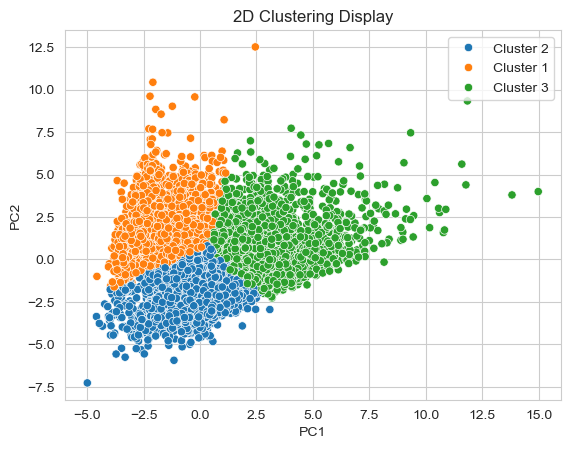

In [47]:
sns.scatterplot(x=reduced['PC1'], y=reduced['PC2'], hue=reduced['KM Cluster'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'}))
plt.legend()
plt.title("2D Clustering Display")
plt.show()

Judging by the 2-Dimensional display of our clustering using only the first and second principal components, the KMeans algorithm seems to have produced very well defined clusters, as observatins of different colour are cleanly separated. It is worth noting here that PC1 and 2, the axes used here account for only about half of the variation in the dataset.

### Agglomerative Hierarchical Clustering

In [48]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

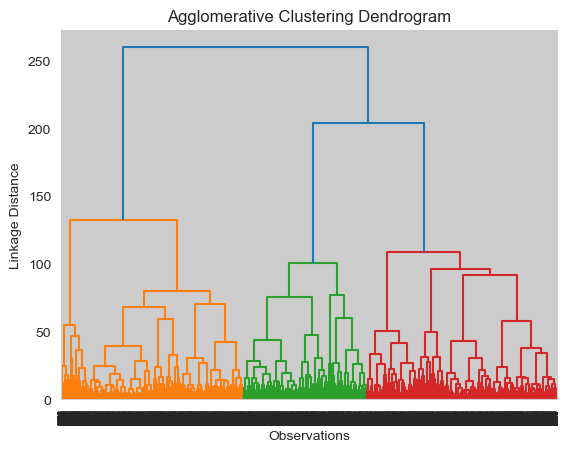

In [49]:
dendrogram(Z=linkage(reduced, method='ward'))
plt.xlabel("Observations")
plt.ylabel("Linkage Distance")
plt.title("Agglomerative Clustering Dendrogram")
plt.show()

Optimal cluster number for agglomerative clustering also seems to be **K=3**

In [50]:
hcl = AgglomerativeClustering(n_clusters=3)
reduced['H Cluster'] = hcl.fit_predict(reduced)

In [51]:
reduced

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,KM Cluster,H Cluster
0,-1.900021,-2.644092,-0.382580,-0.577223,0.058599,0.880569,0.317809,-0.306834,0.300670,0.117975,1,1
1,-2.084596,2.688121,0.293150,0.256743,1.601032,-0.684713,-0.855310,0.686825,-0.866711,-0.474179,0,0
2,1.294262,0.188082,2.132512,-2.076314,-0.920479,-0.475093,0.306823,0.193091,1.048056,-0.137125,2,2
3,-2.306403,-1.457047,0.389194,-2.001389,-0.091930,0.808143,0.169393,0.699752,0.450287,0.660628,1,1
4,0.656480,-0.188943,-1.905282,-1.495208,0.548241,-0.704623,-0.062277,-0.463122,-0.908423,0.974271,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
8632,-3.228720,-4.101509,1.108322,1.413415,-3.653992,0.478688,-1.700635,-0.623020,0.756433,0.724203,1,1
8633,-0.057866,-3.384213,-1.775595,2.039239,-2.770453,-1.804274,-1.348906,0.848331,0.231696,0.005333,1,1
8634,-1.021335,-3.623544,-1.577283,1.606610,-3.224438,-0.994647,-1.602967,-0.002312,0.652250,0.324767,1,1
8635,-4.083404,-2.775654,-0.139266,1.800860,-3.338200,0.159733,-1.753277,1.036166,1.093682,0.150866,1,1


Upon inspection of the first and last 5 observations, both clustering algorithms seem to have predicted similar or identical clustering for our reduced dataset.

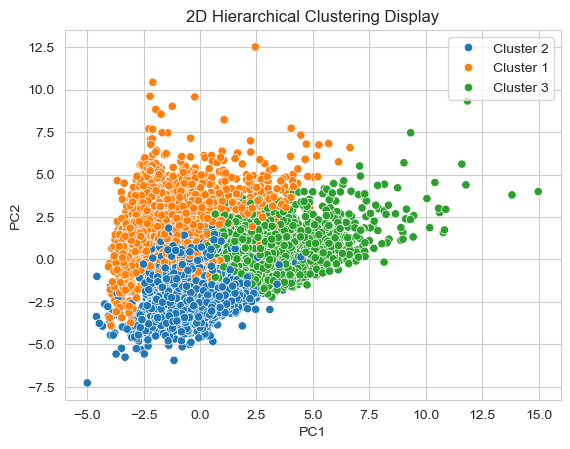

In [52]:
sns.scatterplot(x=reduced['PC1'], y=reduced['PC2'], hue=reduced['H Cluster'].map({0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3'}))
plt.legend()
plt.title('2D Hierarchical Clustering Display')
plt.show()

The Agglomerative Hierarchical clustering, upon visual inspection of the 2D scatterplot, seems to have produced clusters of looser definition than those of the KMeans algorithm. It appears the first and last 5 algorithms were identical by coincidence, and that is not the case throughout the dataset. They do seem to tell the same message, however, as the same colours are gathered in the same corners of the graph as in the KMeans clustering display. It seems revelatory of an inherent grouping of the observations in our dataset.

# Step 5
Now, we assess results of our clusterings, compare performance of both algorithms and make informed inference to present to our imaginary company board.

### Performance Evaluation & Comparison

To begin performance assessment, we train a Decision Tree classifier to predict clusters assigned by each algorithm and assess the classification model's performance as a reflection of how structural and divisive each algorithm's clustering was, alongside other evaluation metrics.

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import silhouette_score

In [54]:
x = reduced.drop(columns=['KM Cluster', 'H Cluster'])
y1 = reduced['KM Cluster']

x_train, x_test, y_train, y_test = train_test_split(x, y1, test_size=0.2, random_state=42)

In [55]:
alphas = np.arange(0.01, 0.1, 0.01) # numpy range can take non integers
models = []

for alpha in alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    km_acc = cross_val_score(dt, x, y1, scoring='accuracy', cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42)).mean()
    km_f1 = cross_val_score(dt, x, y1, scoring='f1_macro', cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42)).mean()
    models.append({
        'Alpha Value': alpha,
        'CV Accuracy': km_acc,
        'CV F1': km_f1
    })

In [56]:
pd.DataFrame(models)

,Alpha Value,CV Accuracy,CV F1
0,0.01,0.955772,0.954437
1,0.02,0.920224,0.920689
2,0.03,0.910965,0.912303
3,0.04,0.910965,0.912303
4,0.05,0.910965,0.912303
5,0.06,0.910965,0.912303
6,0.07,0.910965,0.912303
7,0.08,0.880867,0.878164
8,0.09,0.862452,0.857315


In [57]:
dt = DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)

models.clear()

In [58]:
y2 = reduced['H Cluster']

x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y2, test_size=0.2, random_state=42)

In [59]:
algos = []

def test(col, y):
    ss = silhouette_score(reduced.drop(columns=[reduced.columns[-1], reduced.columns[-2]]), labels=reduced[col], random_state=42)
    acc = cross_val_score(dt, x, y, scoring='accuracy', cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42)).mean()
    f1 = cross_val_score(dt, x, y, scoring='f1_macro', cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42)).mean()
    algos.append({
        'Silhouette Score': ss,
        'Cluster Prediction Accuracy': acc,
        'Cluster Prediction F1': f1
    })

In [60]:
test('KM Cluster', y1)
test('H Cluster', y2)

pd.DataFrame(algos, index=['KMeans Clustering', 'Hierarchical Clustering'])

,Silhouette Score,Cluster Prediction Accuracy,Cluster Prediction F1
KMeans Clustering,0.226033,0.955772,0.954437
Hierarchical Clustering,0.203004,0.890243,0.887077


Above is displayed a tabular performance comparison of both models, which shows that the KMeans clustering exceeded the Hierarchial clusterig in every displayed metric. The Silhouette Score is a maximisation metric in the interval (1, -1) that measures the geometric distance within and between clusters. Also dispalyed are the cross-validated Accuracy and F1 scores of the Decision Tree classifier we trained to predict observation clusters. The fact that we used the same model trained on the same data to predict both targets, yet one exceeds the other in both metrics is telling of the clarity and interpretability of the classifications. Considering this as well as the clear disparity in the divisiveness of the scatterplots displayed earlier, I think we can proceed with our KMeans clustering.

In [61]:
reduced.drop(columns='H Cluster', inplace=True)
reduced.rename({'KM Cluster': 'Cluster'}, inplace=True, axis=1)

In [62]:
cards.reset_index(inplace=True)
cards.drop(columns='index', inplace=True)

cards['Cluster'] = reduced['Cluster']

### Cluster Analysis & Inference

At this point, all we've done is determine that there are three groups of customer behaviour within the dataset. To make this information useful for non-technical company marketers, we proceed to determine what those behaviours are and how they differ and present in an intuitive manner, primarily by visualisation. To start, we once again consult our loadings to make meaning of our principal components.

In [63]:
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
BALANCE,0.034929,0.399796,-0.093344,-0.317191,-0.062664,-0.109188,-0.148427,0.021071,-0.090438,0.096732
BALANCE_FREQUENCY,0.106114,0.208531,-0.277577,-0.373918,-0.164243,-0.196356,0.152109,0.537056,0.264479,-0.258259
PURCHASES,0.356631,-0.099685,0.070151,-0.041847,-0.116208,-0.182277,0.220783,-0.272228,-0.030165,0.222404
ONEOFF_PURCHASES,0.266948,0.061105,0.460225,-0.139382,-0.258922,-0.061018,0.227958,-0.147002,-0.028090,0.093718
INSTALLMENTS_PURCHASES,0.316908,-0.117276,-0.367496,0.092353,0.081766,-0.103363,0.029947,-0.224022,-0.043565,0.012966
CASH_ADVANCE,-0.156594,0.363231,-0.064974,0.192263,-0.036489,-0.009939,0.019297,-0.005055,-0.190828,-0.351919
PURCHASES_FREQUENCY,0.361256,-0.109902,-0.211695,0.027217,-0.110415,-0.154484,0.152024,-0.036344,0.072512,-0.114659
ONEOFF_PURCHASES_FREQUENCY,0.285537,0.057624,0.412421,-0.079499,-0.243877,0.021283,0.137540,0.171586,0.109382,-0.143087
PURCHASES_INSTALLMENTS_FREQUENCY,0.306110,-0.113453,-0.451908,0.087611,0.035849,-0.053941,0.013423,-0.117368,-0.000356,-0.130764
CASH_ADVANCE_FREQUENCY,-0.113591,0.357468,-0.092401,0.319589,-0.123711,0.037407,0.259254,-0.042978,0.168726,-0.007511


In [64]:
from matplotlib.colors import BoundaryNorm, ListedColormap

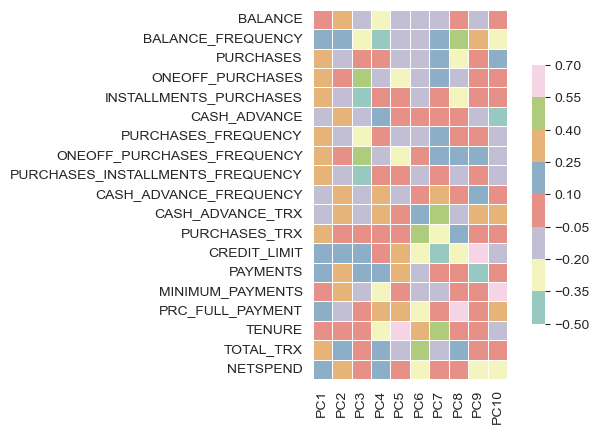

In [65]:
bounds = [-0.5, -0.35, -0.2, -0.05, 0.1, 0.25, 0.4, 0.55, 0.7]
color_map = sns.color_palette("Set3", 8, desat=0.7)
cmap = ListedColormap(color_map) # creating color map from list of colours
norm =  BoundaryNorm(bounds, cmap.N) # bnorm creates discrete colour palette

sns.heatmap(data=loadings, cmap=cmap, norm=norm, linewidths=.5, square=True, cbar_kws={"shrink": .7})
plt.show()

Displayed above is a colour-encoded matrix representing loading magnitude and direction of our Principal Components. Given the specific make-up of each of our PCs, the following inference can be made as to what they represent
| Principal Component | Information Represented | Financial Behaviour Associated |
|:-------------------:|-------------------------|--------------------------------|
| PC1 | Purchase magnitude & frequency | Frequent, heavy or longstanding card usage |
| PC2 | Cash advance magnitude & frequency, balance, payments, netspend | Preference of cash withdrawal, higher spending and debt |
| PC3 | One-off purchase magnitude & frequency, lower installments purchases | Preference of 100% payments on purchases |
| PC4 | Cash advance frequency, lower balance magnitude & frequency, full card payments, lower tenure & minimum payments | Frequent debt clearance, peference of cash withdrawal |
| PC5 | Tenure, credit limit, payments made | Customer loyalty |
| PC6 | Transaction number, tenure, lower netspend | Longstanding but paltry usage |
| PC7 | Tenure, cash advance , lower purchase number & credit limit | Loyatly, preference of cash withdrawal |
| PC8 | Full card payments, balance carryover frequency | Seems contradictory tbh |
| PC9 | Lower payments & netspend | Scant usage |
| PC10 | Minimum payments, lower cash advance & netspend | Nothing apparent |  

Now, that weve established the information represented in our new variables, we proceed to explore clusters.

In [68]:
pc1 = [reduced[reduced['Cluster'] == 0]['PC1'].mean(), reduced[reduced['Cluster'] == 1]['PC1'].mean(), reduced[reduced['Cluster'] == 2]['PC1'].mean()]
pc2 = [reduced[reduced['Cluster'] == 0]['PC2'].mean(), reduced[reduced['Cluster'] == 1]['PC2'].mean(), reduced[reduced['Cluster'] == 2]['PC2'].mean()]
pc3 = [reduced[reduced['Cluster'] == 0]['PC3'].mean(), reduced[reduced['Cluster'] == 1]['PC3'].mean(), reduced[reduced['Cluster'] == 2]['PC3'].mean()]
pc4 = [reduced[reduced['Cluster'] == 0]['PC4'].mean(), reduced[reduced['Cluster'] == 1]['PC4'].mean(), reduced[reduced['Cluster'] == 2]['PC4'].mean()]
cls = ['Cluster 0', 'Cluster 1', 'Cluster 2']

cl_vals = pd.DataFrame({'Cluster': cls, 'PC1': pc1, 'PC2': pc2, 'PC3': pc3, 'PC4': pc4})

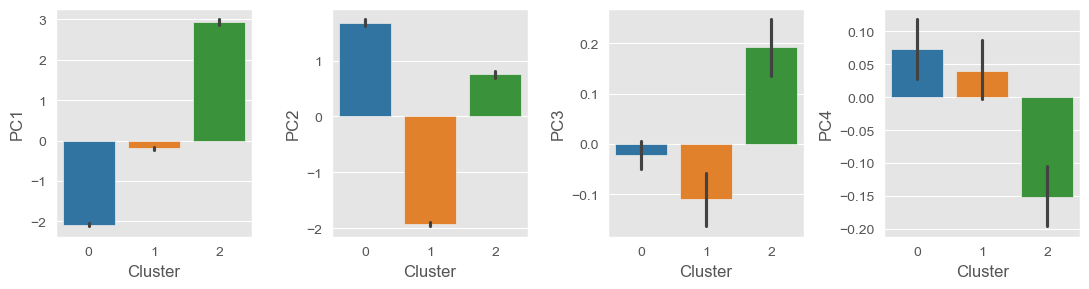

In [66]:
plt.style.use("ggplot")

cols = pd.Series(['PC1', 'PC2', 'PC3', 'PC4'])
fig, ax = plt.subplots(ncols=4, figsize=(11, 3))

for i, col in enumerate(cols):
    sns.barplot(data=reduced, x='Cluster', y=col, palette='tab10', ax=ax[i])
    plt.tight_layout()

In [71]:
print("The following table contains each cluster's mean value in the first four Principal Components")
cl_vals

The following table contains each cluster's mean value in the first four Principal Components


,Cluster,PC1,PC2,PC3,PC4
0,Cluster 0,-2.087099,1.679430,-0.022569,0.072756
1,Cluster 1,-0.194364,-1.927180,-0.110148,0.040203
2,Cluster 2,2.932132,0.750551,0.192976,-0.152108


Inference to be made from the bar charts and table on each cluster's values in the first four combined variables can be summed as follows  
| Cluster | PC1 Value | PC2 Value | PC3 value | PC4 Value |
|:-------:|-----------|-----------|-----------|-----------|
| Zero | Low purchase magnitude & frequency | High cash advance usage, spending and debt | Varying preference of full payments on purchases | Varying but fairly high in debt clearance and cash advance frequency |
| One | Average in purchase magnitude & frequency | Low cash advance usage, spending & debt | Low but varying preference of full payments on purchases | Varying debt clearance behaviour |
| Two | High spenders in purchases | Fairly high cash advance usage, high spending & debt | High preference of full payments on purchases | Low debt clearance|  

Before proceeding to make general inference as to the groupings revealed by these clusters, let us plot clusters against columns of the original dataset as well to explore they values in more specific variables. In doing this, we'll focus on the columns that were'nt represented in the first four principal components.  

Another thing worth noting, however, is that clusters were defined and separated to a much clearer degree in the foremost PCs than in the latter ones among those plotted above. This shows in both the separation between their mean values as the range of their 95% confidence intervals shown in the bar charts. This follows, given that the foremost PCs captured much more variance than those following. It gives us more reason to explore specific variables.  

One more thing to note before we proceed, it is important to keep in mind that there is still natural entropy within these clusters; they can't be perfect categorical segmentations. There will still be slightly varying behaviour within each cluster. We go about segmentation from a fairly general scale, this is just to note that the common attributes in clusters does not mean that each member of that cluster will have the exact same sort of behviour in each label.

In [72]:
# make another such table for specific columns, repeat EDA workflow, final inference, add grouping column